# bb_vwap_ema_v3: return, drawdown and trade risk

[Back to strategy comparison](analysis.ipynb). Run all cells with **Python from the visualizer conda environment**. Money amounts are INR. This notebook recomputes all results from the raw reports.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def find_project_root():
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / "src" / "visualizer" / "strategy_analysis.py").is_file():
            return path
    raise FileNotFoundError("Start Jupyter inside the visualizer repository")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from visualizer.strategy_analysis import (
    load_strategies, comparison_table, strategy_summary, expectancy_stats,
    monthly_table, drawdown_episodes, SimulationConfig, strategy_risk_scenarios,
    risk_win_matrix, SCREENSHOT_REFERENCE, position_size,
)
from visualizer.strategy_charts import (
    expectancy_chart, equity_comparison, equity_small_multiples, heatmap,
    daily_chart, elapsed_day_chart, trade_diagnostics, monthly_chart,
)

get_ipython().run_line_magic("matplotlib", "inline")
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def show_table(frame):
    """Keep exported data numeric; format fractions only for notebook display."""
    percentage_columns = {
        "win_rate", "loss_rate", "total_return", "risk_coverage", "risk_fraction_coverage", "max_trade_drawdown",
        "max_daily_drawdown", "median_risk_fraction", "p95_risk_fraction", "max_risk_fraction",
        "return_fraction", "worst_daily_drawdown", "drawdown_fraction", "risk_fraction",
        "realized_loss_fraction", "success_probability", "drawdown_breach_probability",
        "timeout_probability", "monte_carlo_se",
    }
    fmt = {col: "{:.2%}" if col in percentage_columns else "{:,.2f}"
           for col in frame.select_dtypes(include="number").columns}
    display(frame.style.format(fmt, na_rep="N/A"))

In [2]:
# Editable scenario, not the unknown assumptions behind the screenshot.
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "strategy_report"
SIMULATION = SimulationConfig(
    target_return=0.10,     # reach +10% of starting simulated equity
    max_drawdown=0.10,     # stop at a 10% fall from the running equity peak
    horizon_trades=100,
    paths=5000,
    seed=42,
)
EXPORT = True
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "strategy_analysis"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "strategy"
if EXPORT:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

strategies = load_strategies(RAW_DIR)  # reads ZIP members directly; no extraction needed
summary = comparison_table(strategies)
print(f"Loaded {len(strategies)} strategies from {RAW_DIR}")

Loaded 11 strategies from /home/amit/python/src/github.com/AppsByZubin/visualizer/data/raw/strategy_report


In [3]:
STRATEGY = 'bb_vwap_ema_v3'
data = strategies[STRATEGY]
trades = data.trades
daily = data.daily
print("Source:", data.source)

Source: /home/amit/python/src/github.com/AppsByZubin/visualizer/data/raw/strategy_report/13thsept_files.zip!bb_vwap_ema_v3


## Definitions and data contract

- **Expectancy (INR/trade)** = win rate × average net win − loss rate × absolute average net loss. Rates use **all closed trades**, including breakevens. A value strictly greater than zero passes the requested acceptance screen. Fees are already included in `net_pnl`; do not deduct them again.
- **Realized equity** = initial cash + cumulative closed-trade net P&L. **Cumulative return** = equity / initial cash − 1. Trade curves are ordered by exit timestamp and start at trade zero. Percentages are account returns, not the sum of individual instrument returns.
- **Drawdown** = equity / running peak − 1, with initial capital included in the peak. Daily return = day's realized net P&L / previous day's realized equity. Trade drawdown can be deeper than end-of-day drawdown.
- **Initial stop risk (INR)** = adverse distance from entry to the **first `PLACE_SL` trigger** × original quantity. **Risk per trade** = initial stop risk / realized equity strictly before entry. A later trailing stop in `order_log.csv` is unsuitable for this calculation. `net_r` = net P&L / initial stop risk. Risk excludes fees and slippage, so a realized loss can exceed 1R. It is not a maximum possible loss.
- Equity excludes unrealized P&L, margin requirements and risk from concurrent open positions. Same-timestamp exits are excluded from equity before entry because their within-second ordering is unknown. Missing, delayed or inconsistent original stops remain unknown instead of being guessed.
- Rows without complete closed outcomes are listed separately. Dates without realized closes are carried forward on the calendar; this does not prove those dates had complete market data. First and last months may be partial. Report periods and trade counts differ across strategies.
- Some source end-of-day exits precede their entry by seconds. These rows retain reported P&L and original-stop R for reconciliation/simulation, but holding time, pre-entry equity and percentage risk are unknown. `chronology_errors` counts these rows; repair the source before relying on intraday execution results. Initial-stop coverage and percentage-risk coverage are shown separately.

The supplied order IDs use `MOCK` and report metadata includes a backtest intrabar policy. Treat these as reported simulated outcomes. Positive historical expectancy is a screening result; independent forward/out-of-sample evidence is needed to assess future payouts.

The 95% expectancy interval resamples **whole active exit days** 5,000 times (seed 42), preserving within-day trade dependence. It assumes independent days and does not account for selecting the best strategy from many trials.

Formula references: [CME: mathematical expectation](https://www.cmegroup.com/education/courses/trading-psychology/the-mathematics-of-trading-success) and [CME: position size from stop distance and account risk](https://www.cmegroup.com/education/courses/trade-and-risk-management/proper-position-size).

## Data quality and expectancy
Acceptance follows the requested rule: net expectancy strictly greater than zero.

In [4]:
display(data.checks)
assert data.checks.passed.all(), "Reconciliation failed: inspect the table above"
row = summary.loc[[STRATEGY]]
show_table(row[["trades", "wins", "losses", "breakevens", "excluded_rows", "win_rate", "avg_win", "avg_loss", "expectancy", "expectancy_ci_low", "expectancy_ci_high", "profit_factor"]])
decision = "ACCEPT: positive net expectancy" if row.expectancy_positive.iloc[0] else "REJECT: non-positive net expectancy"
display(Markdown(f"**{decision}**"))
if not data.excluded.empty:
    display(data.excluded[["id", "timestamp", "status", "exclusion_reason"]])
chronology_issues = trades.loc[~trades.chronology_valid]
if not chronology_issues.empty:
    display(Markdown("**Source chronology errors (holding time and percentage risk unknown):**"))
    display(chronology_issues[["id", "timestamp", "exit_time", "status", "net_pnl"]])
show_table(row[["initial_cash", "start_date", "end_date", "active_days", "net_pnl", "charges", "total_return", "max_daily_drawdown", "max_trade_drawdown", "max_loss_streak"]])

,check,absolute_error,passed
0,Gross P&L minus charges equals net P&L (max ro...,0.0000,True
1,Daily dates cover every realized exit date,0.0000,True
2,Daily net P&L (max day error),0.0000,True
3,Daily closed trade counts (max day error),0.0000,True
4,Daily equity (max day error),0.0000,True
5,Report net P&L,-0.0000,True
6,Report gross P&L,0.0000,True
7,Report charges,0.0000,True
8,Report closed trade count,0.0000,True
9,Report current cash,0.0000,True


,trades,wins,losses,breakevens,excluded_rows,win_rate,avg_win,avg_loss,expectancy,expectancy_ci_low,expectancy_ci_high,profit_factor
strategy,,,,,,,,,,,,
bb_vwap_ema_v3,315.00,154.00,161.00,0.00,1.00,48.89%,"5,994.06","3,049.56","1,371.76",591.33,"2,219.12",1.88


**ACCEPT: positive net expectancy**

,id,timestamp,status,exclusion_reason
99,179902e6,2026-04-02 11:38:09,OPEN,Open position; no realized outcome


,initial_cash,start_date,end_date,active_days,net_pnl,charges,total_return,max_daily_drawdown,max_trade_drawdown,max_loss_streak
strategy,,,,,,,,,,
bb_vwap_ema_v3,"100,000.00",2025-12-31 00:00:00,2026-09-11 00:00:00,140.00,"432,105.95","77,310.70",432.11%,-11.41%,-13.13%,12.00


## Return and drawdown vs days
Calendar dates include days without a realized close. Daily drawdown uses end-of-day realized equity and a running peak that starts at initial capital.

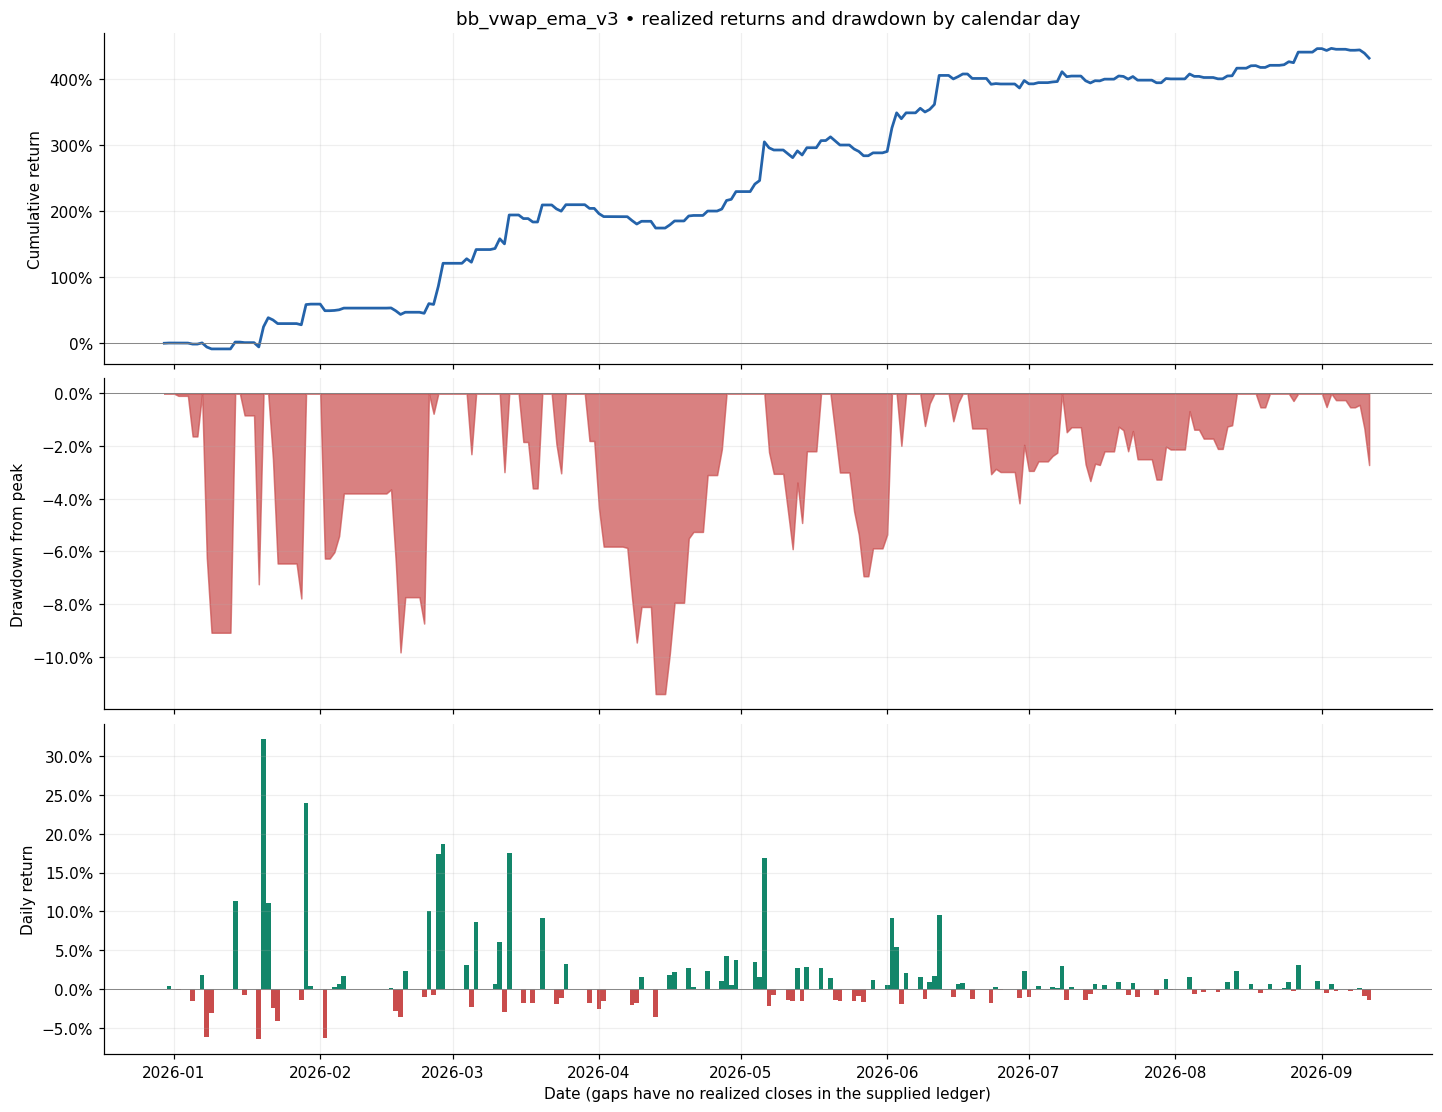

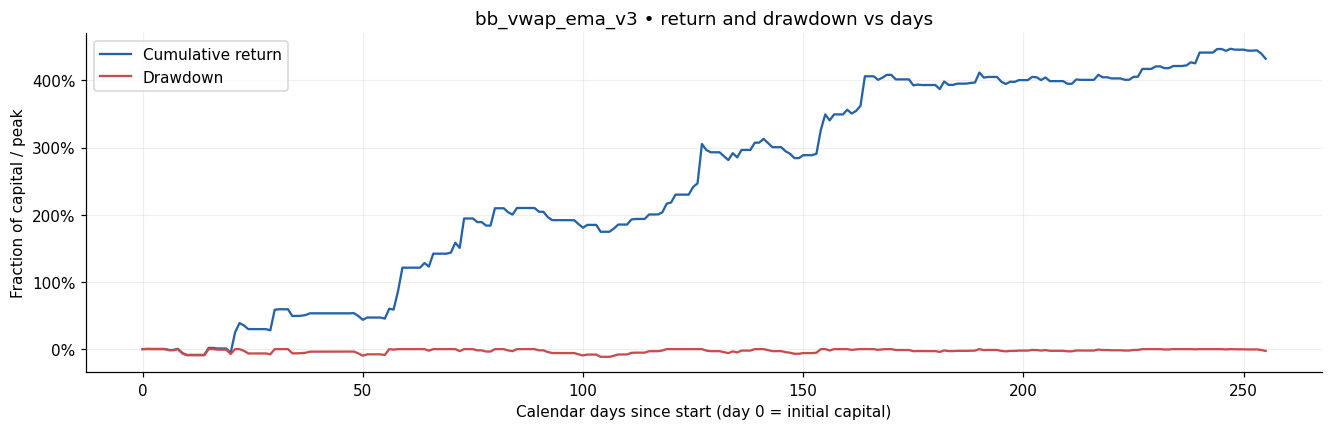

,net_pnl,num_trades,reported_day,equity,equity_before_day,daily_return,cumulative_return,peak_equity,drawdown,drawdown_fraction,elapsed_days
date,,,,,,,,,,,
2026-08-28,0.0000,0,False,"541,258.6008","541,258.6008",0.0000,4.4126,"541,258.6008",0.0000,0.0000,241
2026-08-29,0.0000,0,False,"541,258.6008","541,258.6008",0.0000,4.4126,"541,258.6008",0.0000,0.0000,242
2026-08-30,0.0000,0,False,"541,258.6008","541,258.6008",0.0000,4.4126,"541,258.6008",0.0000,0.0000,243
2026-08-31,"5,294.2810",2,True,"546,552.8818","541,258.6008",0.0098,4.4655,"546,552.8818",0.0000,0.0000,244
2026-09-01,0.0000,0,False,"546,552.8818","546,552.8818",0.0000,4.4655,"546,552.8818",0.0000,0.0000,245
2026-09-02,"-2,807.3944",2,True,"543,745.4874","546,552.8818",-0.0051,4.4375,"546,552.8818","-2,807.3944",-0.0051,246
2026-09-03,"3,220.7133",2,True,"546,966.2007","543,745.4874",0.0059,4.4697,"546,966.2007",0.0000,0.0000,247
2026-09-04,"-1,381.3397",1,True,"545,584.8610","546,966.2007",-0.0025,4.4558,"546,966.2007","-1,381.3397",-0.0025,248
2026-09-05,0.0000,0,False,"545,584.8610","545,584.8610",0.0000,4.4558,"546,966.2007","-1,381.3397",-0.0025,249


In [5]:
fig = daily_chart(data)
if EXPORT:
    fig.savefig(FIGURE_DIR / f"{STRATEGY}_daily.png", dpi=160, bbox_inches="tight")
plt.show()
fig = elapsed_day_chart(data)
plt.show()
display(daily.tail(15))

## Monthly returns and drawdown recovery
Monthly return uses beginning-of-month equity. The worst daily drawdown column measures the fall from the full-history peak. Episode duration counts calendar days from peak to recovery, or to the end of the sample if unrecovered.

,net_pnl,trades,beginning_equity,ending_equity,worst_daily_drawdown,reported_days,return_fraction
date,,,,,,,
2025-12,359.16,2.00,"100,000.00","100,359.16",0.00%,1.00,0.36%
2026-01,"58,951.72",33.00,"100,359.16","159,310.88",-9.08%,15.00,58.74%
2026-02,"61,883.16",30.00,"159,310.88","221,194.04",-9.83%,13.00,38.84%
2026-03,"83,197.68",31.00,"221,194.04","304,391.72",-3.60%,14.00,37.61%
2026-04,"25,484.96",40.00,"304,391.72","329,876.68",-11.41%,16.00,8.37%
2026-05,"58,697.05",47.00,"329,876.68","388,573.73",-6.94%,19.00,17.79%
2026-06,"109,625.51",48.00,"388,573.73","498,199.24",-5.36%,19.00,28.21%
2026-07,"2,473.96",44.00,"498,199.24","500,673.20",-3.33%,20.00,0.50%
2026-08,"45,879.68",27.00,"500,673.20","546,552.88",-2.13%,16.00,9.16%


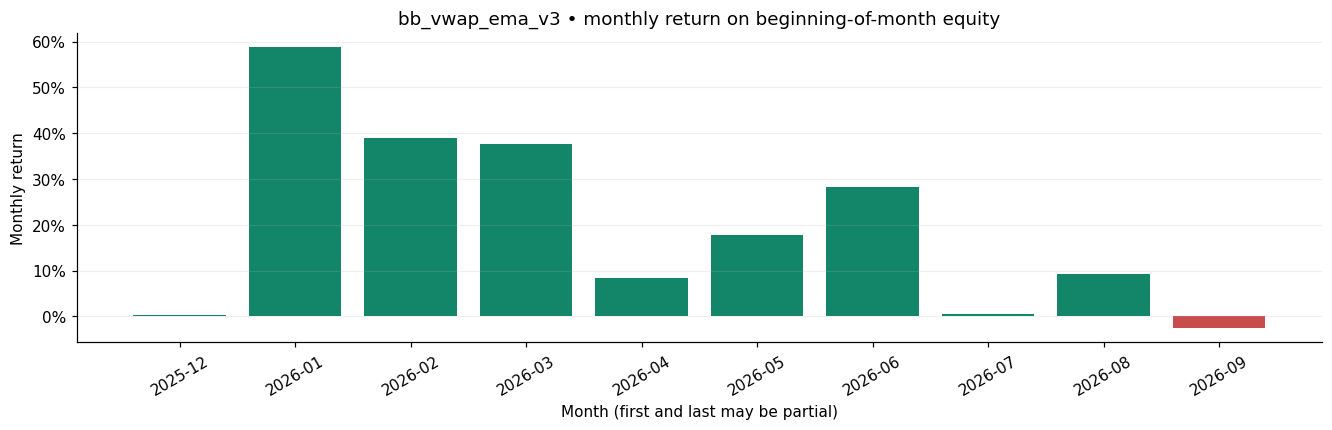

,peak_date,trough_date,recovery_date,drawdown_fraction,duration_days,recovered
10,2026-03-29 00:00:00,2026-04-13 00:00:00,2026-04-28 00:00:00,-11.41%,30.00,True
4,2026-02-01 00:00:00,2026-02-18 00:00:00,2026-02-24 00:00:00,-9.83%,23.00,True
1,2026-01-07 00:00:00,2026-01-09 00:00:00,2026-01-14 00:00:00,-9.08%,7.00,True
3,2026-01-21 00:00:00,2026-01-28 00:00:00,2026-01-29 00:00:00,-7.78%,8.00,True
2,2026-01-15 00:00:00,2026-01-19 00:00:00,2026-01-20 00:00:00,-7.24%,5.00,True
12,2026-05-20 00:00:00,2026-05-27 00:00:00,2026-06-02 00:00:00,-6.94%,13.00,True
11,2026-05-06 00:00:00,2026-05-12 00:00:00,2026-05-18 00:00:00,-5.91%,12.00,True
16,2026-06-18 00:00:00,2026-06-29 00:00:00,2026-07-08 00:00:00,-4.17%,20.00,True
8,2026-03-15 00:00:00,2026-03-18 00:00:00,2026-03-20 00:00:00,-3.60%,5.00,True
17,2026-07-08 00:00:00,2026-07-14 00:00:00,2026-08-14 00:00:00,-3.33%,37.00,True


In [6]:
monthly = monthly_table(data)
show_table(monthly)
fig = monthly_chart(monthly, STRATEGY)
plt.show()
episodes = drawdown_episodes(data)
show_table(episodes.head(10))

## Trade-level edge and stability
The rolling mean uses the last 30 completed trades. Outcome signs come from net P&L: a `STOPLOSS HIT` may still be a winner after a trailing stop.

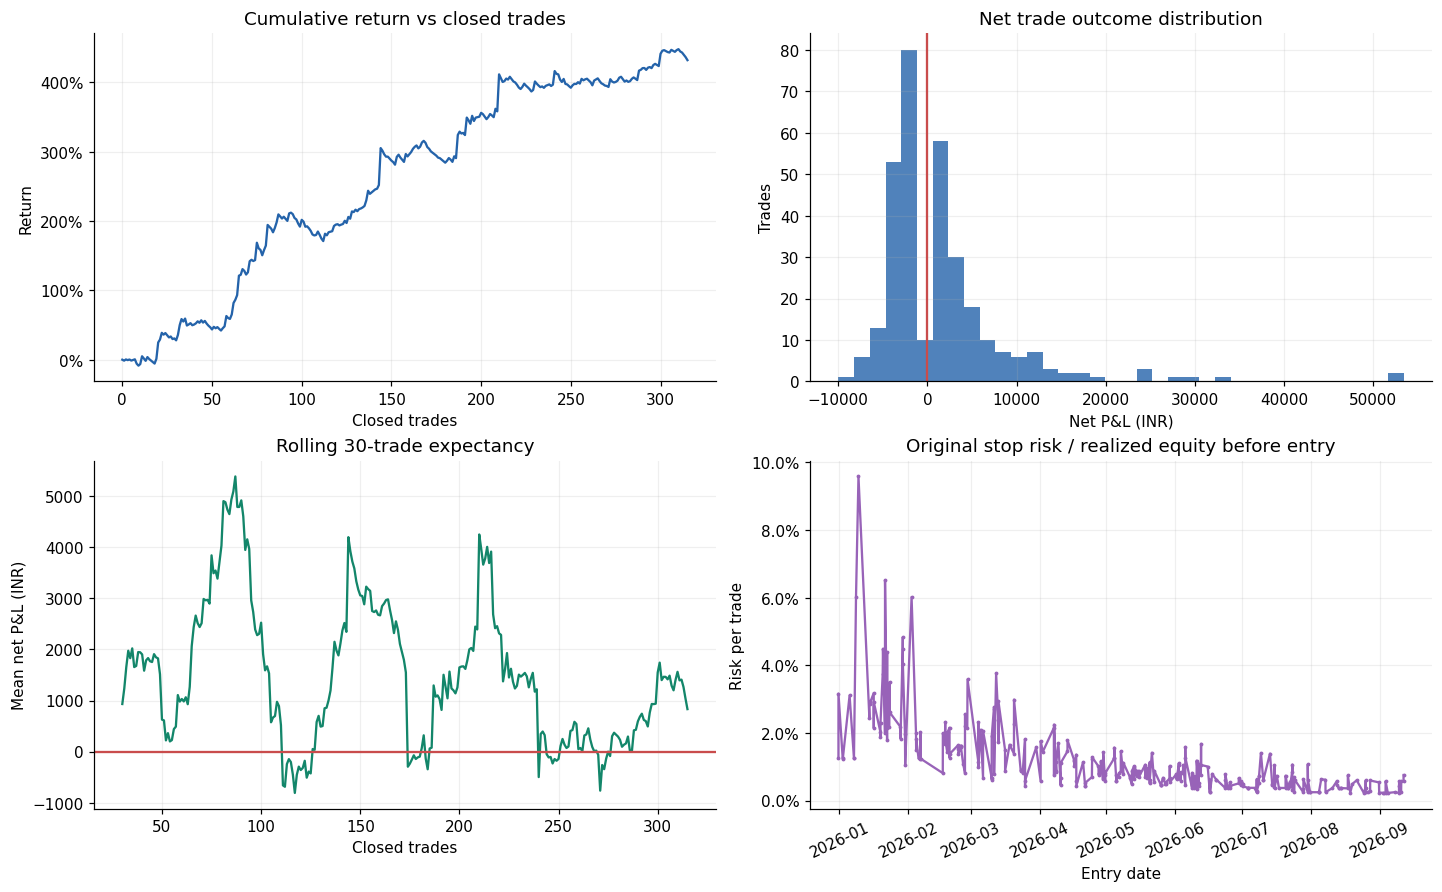

In [7]:
fig = trade_diagnostics(data)
if EXPORT:
    fig.savefig(FIGURE_DIR / f"{STRATEGY}_trades.png", dpi=160, bbox_inches="tight")
plt.show()

## Risk per trade and the screenshot

The screenshot supplies risk rows **0.25%, 0.5%, 1%, 1.5%, 2.5%, 4%** and win-rate columns **40%–90%**, but no definition of the percentages inside it. Its numbers are retained below **only as a reference**, not attributed to these strategies.

Our separate, editable simulation measures **the probability of reaching the configured return target before breaching the configured peak-to-trough drawdown limit, within the configured number of trades**. These are example assumptions, not inferred screenshot settings or provider payout rules.

Each path starts at equity 1 and updates as `equity *= max(0, 1 + risk_fraction * sampled_net_R)`. Target and drawdown checks occur after every trade; hitting either barrier ends that path. A drawdown breach takes precedence; a path hitting neither barrier is a timeout.

The observed-win-rate table resamples the strategy's full empirical net-R distribution. The win-rate grid varies the probability of winning while sampling the strategy's observed winning and losing R sizes separately, retaining the observed breakeven rate. It therefore shows sensitivity to hypothetical win rates, not validated improvement in the strategy.

Trades are sampled independently with replacement; streak dependence and regime shifts can make real risk worse. Historical net-R includes recorded charges; scaling it assumes costs and fills scale proportionally, ignores lot sizes, and is a research approximation. `monte_carlo_se` measures simulation noise only, not uncertainty in the historical sample. No risk level is automatically recommended.

,median_risk_fraction,p95_risk_fraction,max_risk_fraction,risk_coverage,risk_fraction_coverage,mean_net_r
strategy,,,,,,
bb_vwap_ema_v3,0.79%,3.02%,9.58%,100.00%,100.00%,0.37


,id,timestamp,entry_price,initial_stop,initial_qty,initial_risk,equity_before_entry,risk_fraction,net_pnl,net_r,realized_loss_fraction
0,53ec78ce,2025-12-31 14:41:29,127.40,122.60,260.00,"1,248.00","100,000.00",1.25%,"-1,371.32",-1.10,1.37%
1,0c92a787,2025-12-31 15:02:09,109.40,104.60,650.00,"3,120.00","98,628.68",3.16%,"1,730.49",0.55,0.00%
2,4e935197,2026-01-02 12:51:26,93.50,88.70,260.00,"1,248.00","100,359.16",1.24%,-961.18,-0.77,0.96%
3,565a179a,2026-01-02 14:34:14,66.00,61.20,260.00,"1,248.00","99,397.98",1.26%,872.27,0.70,0.00%
4,df765668,2026-01-05 14:52:37,46.90,42.10,650.00,"3,120.00","100,270.26",3.11%,"-1,546.72",-0.50,1.54%
5,8f01f6f1,2026-01-07 13:03:18,119.65,114.85,260.00,"1,248.00","98,723.54",1.26%,981.93,0.79,0.00%
6,496f389c,2026-01-07 14:00:27,141.20,136.40,260.00,"1,248.00","99,705.47",1.25%,825.93,0.66,0.00%
7,26e5ee78,2026-01-08 12:06:54,117.65,108.35,650.00,"6,045.00","100,531.40",6.01%,"-6,261.87",-1.04,6.23%
8,2d64b8ac,2026-01-09 14:45:09,189.90,176.00,650.00,"9,035.00","94,269.53",9.58%,"-2,869.94",-0.32,3.04%
9,70c11277,2026-01-14 12:13:14,137.70,131.95,390.00,"2,242.50","91,399.59",2.45%,"2,241.96",1.00,0.00%


Simulation settings: SimulationConfig(target_return=0.1, max_drawdown=0.1, horizon_trades=100, paths=5000, seed=42)


,risk_fraction,success_probability,drawdown_breach_probability,timeout_probability,monte_carlo_se
0,0.25%,51.08%,0.00%,48.92%,0.71%
1,0.50%,85.68%,0.84%,13.48%,0.50%
2,1.00%,87.22%,12.12%,0.66%,0.47%
3,1.50%,77.94%,22.06%,0.00%,0.59%
4,2.50%,65.68%,34.32%,0.00%,0.67%
5,4.00%,58.34%,41.66%,0.00%,0.70%


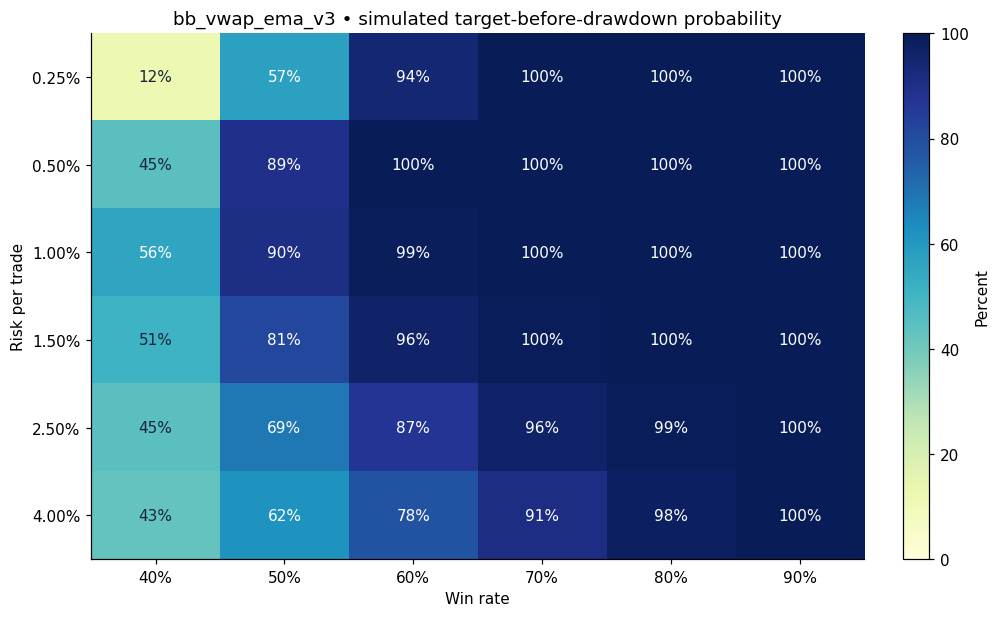

In [8]:
show_table(row[["median_risk_fraction", "p95_risk_fraction", "max_risk_fraction", "risk_coverage", "risk_fraction_coverage", "mean_net_r"]])
show_table(trades[["id", "timestamp", "entry_price", "initial_stop", "initial_qty", "initial_risk", "equity_before_entry", "risk_fraction", "net_pnl", "net_r", "realized_loss_fraction"]].head(12))
print("Simulation settings:", SIMULATION)
risk_scenarios = strategy_risk_scenarios(data, SIMULATION)
show_table(risk_scenarios.reset_index())
matrix = risk_win_matrix(data, SIMULATION)
fig = heatmap(matrix, f"{STRATEGY} • simulated target-before-drawdown probability")
if EXPORT:
    fig.savefig(FIGURE_DIR / f"{STRATEGY}_risk_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

## Position-size calculation
Budget = account equity × selected risk fraction. Quantity = floor(budget / risk per unit), rounded down to the configured lot size. The example uses the first trade's original stop and starting account equity. Edit the inputs for your intended trade; `LOT_SIZE = 1` shows unconstrained units and does not assert an exchange lot size. Estimated costs are an input, and margin/premium affordability needs separate evaluation.

In [9]:
EXAMPLE_RISK_FRACTION = 0.01  # illustration, not a recommendation
LOT_SIZE = 1                # replace with the applicable contract lot size
ESTIMATED_COST_PER_UNIT = 0.0
example = trades.sort_values("timestamp").iloc[0]
sizing = position_size(
    account_equity=data.initial_cash,
    risk_fraction=EXAMPLE_RISK_FRACTION,
    entry_price=example.entry_price,
    stop_price=example.initial_stop,
    lot_size=LOT_SIZE,
    cost_per_unit=ESTIMATED_COST_PER_UNIT,
)
display(pd.Series(sizing, name="Illustrative position size").to_frame())

,Illustrative position size
risk_budget,"1,000.0000"
units,208.0000
lots,208.0000
estimated_risk,998.4000


## Export full analysis
Normalized trades include the original stop, pre-entry equity, initial risk, net R, realized equity and drawdown. Calendar-day CSVs retain decimal fractions (`0.01 = 1%`).

In [10]:
if EXPORT:
    dest = OUTPUT_DIR / STRATEGY
    dest.mkdir(parents=True, exist_ok=True)
    trades.to_csv(dest / "trades.csv", index=False)
    daily.to_csv(dest / "daily.csv")
    monthly.to_csv(dest / "monthly.csv")
    episodes.to_csv(dest / "drawdown_episodes.csv", index=False)
    risk_scenarios.to_csv(dest / "risk_scenarios.csv")
    matrix.to_csv(dest / "risk_win_matrix.csv")
    data.excluded.to_csv(dest / "excluded_orders.csv", index=False)
    print(f"Saved full analysis to {dest}")

Saved full analysis to /home/amit/python/src/github.com/AppsByZubin/visualizer/data/processed/strategy_analysis/bb_vwap_ema_v3
